In [2]:
import sleap
import sys
import json
import os

sys.path.append('..')
from python.polygon_based_correction import *
from python.animation import *
from eval.eval import *
from python.dataset_conversion import *

sleap.versions()
sleap.system_summary()

SLEAP: 1.4.1
TensorFlow: 2.7.0
Numpy: 1.21.5
Python: 3.7.12
OS: Linux-6.8.0-51-generic-x86_64-with-debian-trixie-sid
GPUs: 2/2 available
  Device: /physical_device:GPU:0
         Available: True
       Initialized: False
     Memory growth: None
  Device: /physical_device:GPU:1
         Available: True
       Initialized: False
     Memory growth: None


In [4]:
dataset_path = '/home/mingxiao/Desktop/jellyfish/video/video_1_clips/correction_test/a1_1h_1m_w_scores.slp'
dataset = sleap.load_file(dataset_path)
print(dataset)

Labels(labeled_frames=9000, videos=1, skeletons=1, tracks=17)


In [5]:
multi_4k_points_path = '/home/mingxiao/Desktop/jellyfish/label/multifish/predictions/multifish_animal_1_v10_predicted_points_with_score.npy'
multi_4k_points = np.load(multi_4k_points_path)
print(multi_4k_points.shape)
start_idx = 150 * 60 * 60
end_idx = 150 * 60 * 61
multi_pts_clip = multi_4k_points[start_idx:end_idx]
print(multi_pts_clip.shape)

(3240000, 17, 3)
(9000, 17, 3)


# ID mispredicted points

In [16]:
def plot_nn_dist(frame_pts):
    pt_cnt = frame_pts.shape[0]
    nn_dists = []
    for i in range(pt_cnt):
        pt = frame_pts[i]
        dists = np.linalg.norm(frame_pts[np.arange(pt_cnt) != i] - pt, axis=1)
        nn_dists.append(np.min(dists))
    nn_dists = np.array(nn_dists)
    print(f'min nn dist: {np.min(nn_dists):.2f}, max nn dist: {np.max(nn_dists):.2f}')
    plt.hist(nn_dists, bins=pt_cnt)
    plt.xlabel('Nearest Neighbor Distance')
    plt.ylabel('Count')
    plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Force integer y-axis ticks
    plt.show()

min nn dist: 4.07, max nn dist: 21.01


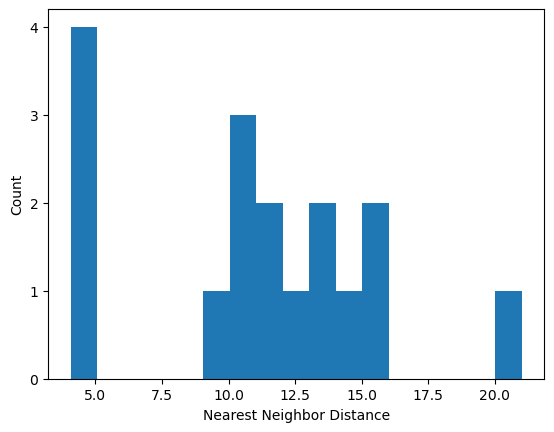

In [18]:
frame_idx = 50
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.47, max nn dist: 19.55


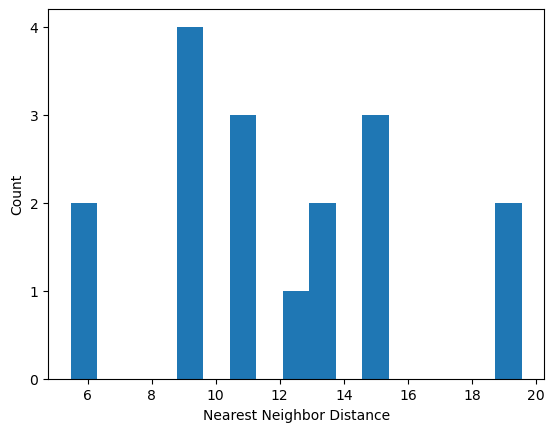

In [19]:
frame_idx = 51
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 8.58, max nn dist: 19.83


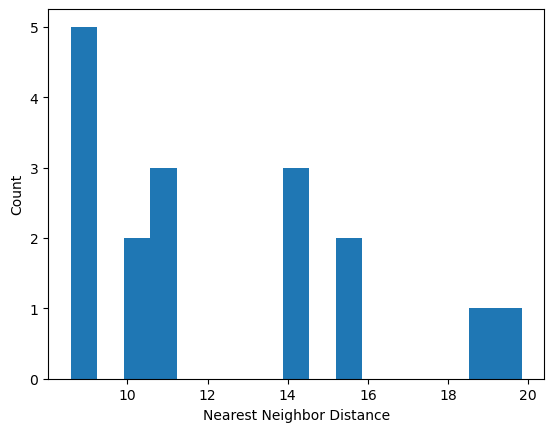

In [20]:
frame_idx = 53
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.73, max nn dist: 24.72


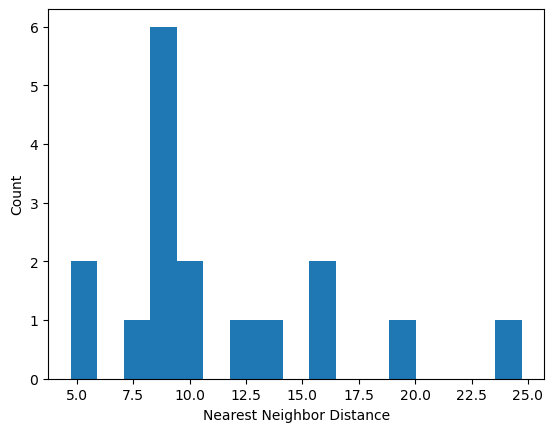

In [23]:
frame_idx = 56
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 5.21, max nn dist: 18.02


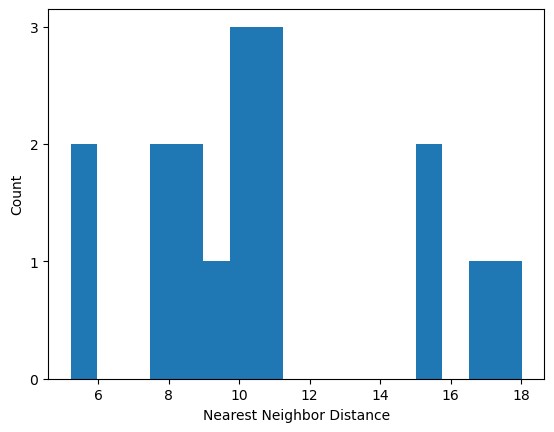

In [28]:
frame_idx = 61
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

min nn dist: 4.93, max nn dist: 14.59


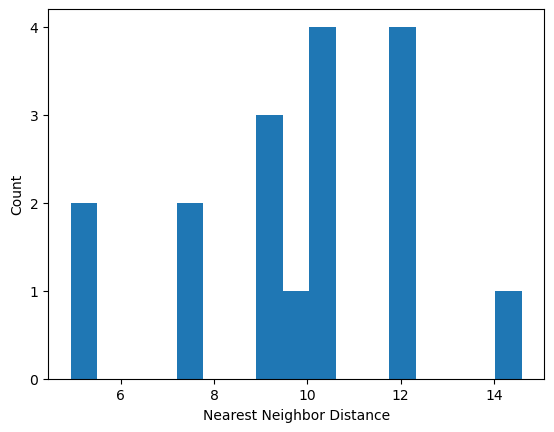

In [30]:
frame_idx = 66
plot_nn_dist(multi_pts_clip[frame_idx, :, :2])

# Assign point ID to the rest

# Interpolation

# Polygon-based correction